In [57]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [58]:
df1 = pd.read_csv('cleaned_dataset.csv',index_col=False)
df2 = pd.read_csv('temp_imp.csv')

In [59]:
df1.sample(5)

,Unnamed: 0,PM2.5,PM10,TSP
2564,2024-10-11,34.933692,60.124217,115.962318
326,2017-07-17,15.848460,77.198230,276.777100
1762,2021-11-22,46.380650,84.000000,179.900000
1741,2021-10-05,19.131951,34.506383,82.355319
504,2018-01-11,119.996200,215.417400,366.312100


In [60]:
df1.rename(columns={'Unnamed: 0' : 'datetime'},inplace=True)

In [61]:
df2.sample(5)

,datetime,temp,humidity,windspeed,winddir,sealevelpressure,visibility,precipitation,solarradiation
1650,2020-07-09,74.1,94.4,8.1,55.0,1008.1,4.1,3.4036,99.6
424,2017-03-01,60.8,65.9,10.3,268.6,1017.6,3.1,0.0000,226.5
237,2016-08-26,74.5,81.3,12.8,171.4,1015.7,4.9,15.5000,231.4
1692,2020-08-20,73.8,90.6,16.1,214.9,1010.8,4.7,3.2004,214.8
2837,2023-10-09,70.6,79.3,9.2,258.0,1016.8,3.9,0.0000,171.6


In [62]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2646 entries, 0 to 2645
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   datetime  2646 non-null   object 
 1   PM2.5     2646 non-null   float64
 2   PM10      2646 non-null   float64
 3   TSP       2646 non-null   float64
dtypes: float64(3), object(1)
memory usage: 82.8+ KB


In [63]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3468 entries, 0 to 3467
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   datetime          3468 non-null   object 
 1   temp              3468 non-null   float64
 2   humidity          3468 non-null   float64
 3   windspeed         3468 non-null   float64
 4   winddir           3468 non-null   float64
 5   sealevelpressure  3468 non-null   float64
 6   visibility        3468 non-null   float64
 7   precipitation     3468 non-null   float64
 8   solarradiation    3468 non-null   float64
dtypes: float64(8), object(1)
memory usage: 244.0+ KB


In [64]:
df1['datetime']=pd.to_datetime(df1['datetime'])
df2['datetime']=pd.to_datetime(df2['datetime'])

In [65]:
merge_df_comp = pd.merge(df1,df2,on='datetime',how='inner')

In [66]:
merge_df_comp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2646 entries, 0 to 2645
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   datetime          2646 non-null   datetime64[ns]
 1   PM2.5             2646 non-null   float64       
 2   PM10              2646 non-null   float64       
 3   TSP               2646 non-null   float64       
 4   temp              2646 non-null   float64       
 5   humidity          2646 non-null   float64       
 6   windspeed         2646 non-null   float64       
 7   winddir           2646 non-null   float64       
 8   sealevelpressure  2646 non-null   float64       
 9   visibility        2646 non-null   float64       
 10  precipitation     2646 non-null   float64       
 11  solarradiation    2646 non-null   float64       
dtypes: datetime64[ns](1), float64(11)
memory usage: 248.2 KB


In [67]:
merge_df_comp.shape

(2646, 12)

In [68]:
merge_df_comp.tail(10)

,datetime,PM2.5,PM10,TSP,temp,humidity,windspeed,winddir,sealevelpressure,visibility,precipitation,solarradiation
2636,2024-12-22,78.522470,105.436139,152.817679,51.1,76.6,10.3,227.9,1019.6,4.0,0.0,164.2
2637,2024-12-23,87.761875,115.394097,151.858677,51.3,73.7,6.9,122.2,1020.0,3.6,0.0,161.0
2638,2024-12-24,91.520972,124.643056,171.017639,51.1,74.6,6.9,182.9,1020.3,3.4,0.0,155.1
2639,2024-12-25,86.244097,119.947222,176.158680,54.2,68.9,10.3,317.1,1021.5,3.9,0.2,127.1
2640,2024-12-26,77.334728,109.378378,163.747977,52.1,67.2,9.2,268.3,1024.0,4.2,0.0,174.7
2641,2024-12-27,90.031286,122.154243,161.637471,52.5,69.4,4.7,160.8,1024.1,3.7,0.0,175.9
2642,2024-12-28,115.462085,150.554242,191.303695,51.5,76.6,4.7,131.1,1023.8,2.8,2.0,67.2
2643,2024-12-29,104.691319,139.022639,201.824028,54.8,68.3,11.4,257.4,1021.4,3.3,1.6,137.5
2644,2024-12-30,81.418264,107.658472,139.620417,52.4,71.1,8.1,204.3,1020.5,4.1,0.0,150.8
2645,2024-12-31,84.058125,107.694306,140.288750,52.6,74.8,10.3,272.5,1021.7,3.6,0.0,155.8


In [69]:
merge_df_comp.sort_values('datetime',inplace=True)

In [70]:
merge_df_comp.isnull().sum()

datetime            0
PM2.5               0
PM10                0
TSP                 0
temp                0
humidity            0
windspeed           0
winddir             0
sealevelpressure    0
visibility          0
precipitation       0
solarradiation      0
dtype: int64

In [83]:
merge_df_comp.to_csv('Dataset_AQI_temp_Clear.csv',index=False)

In [72]:
merge_df_comp['precipitation'].value_counts()

precipitation
0.0000      1586
0.3000        54
0.5000        45
1.5000        33
1.0000        32
            ... 
12.8000        1
97.0000        1
164.3000       1
18.0086        1
0.6000         1
Name: count, Length: 330, dtype: int64

## Verfying the merged dataset

#### checking shape

In [73]:
merge_df_comp.shape

(2646, 12)

In [74]:
merge_df_comp.columns

Index(['datetime', 'PM2.5', 'PM10', 'TSP', 'temp', 'humidity', 'windspeed',
       'winddir', 'sealevelpressure', 'visibility', 'precipitation',
       'solarradiation'],
      dtype='object')

In [75]:
merge_df_comp.isnull().sum()

datetime            0
PM2.5               0
PM10                0
TSP                 0
temp                0
humidity            0
windspeed           0
winddir             0
sealevelpressure    0
visibility          0
precipitation       0
solarradiation      0
dtype: int64

In [76]:
merge_df_comp['datetime'].duplicated().sum()

np.int64(0)

In [77]:
print(merge_df_comp['datetime'].min())
print(merge_df_comp['datetime'].max())

2016-08-25 00:00:00
2024-12-31 00:00:00


In [78]:
common_dates = set(df1['datetime']) & set(df2['datetime'])
print(len(common_dates))
print(len(merge_df_comp))

2646
2646


<Axes: xlabel='datetime'>

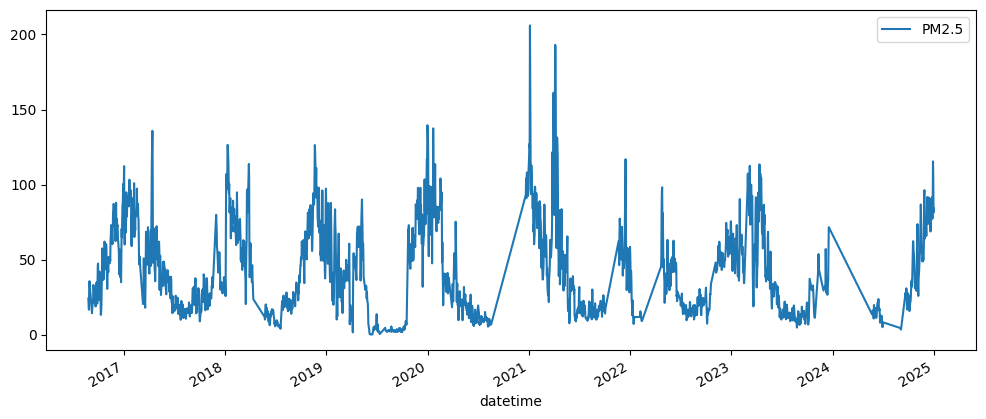

In [79]:
merge_df_comp.plot(
    x='datetime',
    y='PM2.5',
    figsize=(12,5)
)

In [80]:
df_original = pd.read_csv('Dataset/Complete_dataset.csv')

In [81]:
df_original['date'] = pd.to_datetime(df_original['date'])

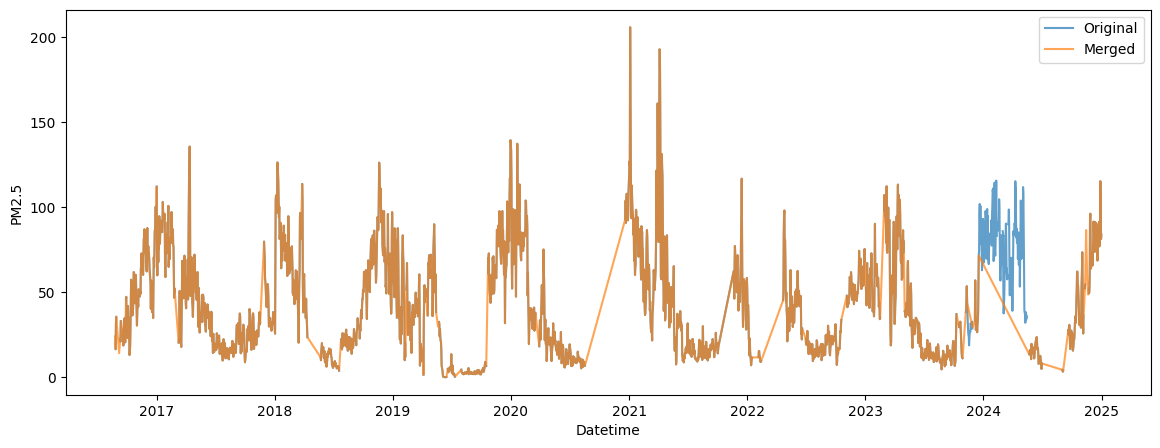

<Figure size 640x480 with 0 Axes>

In [82]:
plt.figure(figsize=(14,5))

plt.plot(
    df_original['date'],
    df_original['PM2.5'],
    label='Original',
    alpha=0.7
)

plt.plot(
    merge_df_comp['datetime'],
    merge_df_comp['PM2.5'],
    label='Merged',
    alpha=0.7
)

plt.legend()
plt.xlabel("Datetime")
plt.ylabel("PM2.5")
plt.show()
plt.savefig('interpolation_5.png')